## Data exploration and visualization

Before building models or drawing conclusions, we need to understand the structure, quality, and content of the dataset. The exploration below is organized to answer a sequence of questions: **What do we have?** (structure and sample), **Is the data usable?** (types and missing values), **What does each variable look like?** (categorical breakdowns), and **How do key outcomes vary?** (salary by experience level). The first code block loads the data and inspects shape and sample rows to assess scale and confirm columns. The second block examines data types and missing values to identify cleaning needs and validate that numeric columns are interpreted correctly. The third block explores categorical columns (country, job_role, experience_level, etc.) to see class distributions and spot imbalances or rare categories that might affect downstream analysis. The final block summarizes salary and bonus by experience level to ground our understanding of compensation structure before we move to visualizations and modeling.


In [7]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv("global_ai_jobs.csv")

# Basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()


Shape: (90000, 35)

First 5 rows:


,id,country,job_role,ai_specialization,experience_level,experience_years,salary_usd,bonus_usd,education_required,industry,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
0,1,UAE,Machine Learning Engineer,Reinforcement Learning,Entry,0,66465,5395,Master,Automotive,...,27,12,76,57,65,73,15,55,1.23,76
1,2,USA,AI Engineer,LLM,Entry,1,75507,11713,Bootcamp,Retail,...,27,54,29,69,60,51,15,58,0.87,67
2,3,Brazil,Research Scientist,Analytics,Entry,0,41660,5268,PhD,Healthcare,...,13,12,49,70,59,68,37,13,2.13,61
3,4,India,Software Engineer AI,Computer Vision,Senior,6,43268,7975,Diploma,Tech,...,30,80,47,79,65,55,46,74,1.49,56
4,5,Germany,Machine Learning Engineer,Computer Vision,Entry,0,69119,4758,Master,Retail,...,24,82,47,64,52,69,17,21,0.87,72


In [8]:
# Data types and missing values
print("Data types:\n", df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())
print("\nSummary statistics for numeric columns:")
df.describe()

Data types:
 id                           int64
country                     object
job_role                    object
ai_specialization           object
experience_level            object
experience_years             int64
salary_usd                   int64
bonus_usd                    int64
education_required          object
industry                    object
company_size                object
interview_rounds             int64
year                         int64
work_mode                   object
weekly_hours               float64
company_rating             float64
job_openings                 int64
hiring_difficulty_score    float64
layoff_risk                float64
ai_adoption_score            int64
company_funding_billion    float64
economic_index             float64
ai_maturity_years            int64
offer_acceptance_rate      float64
tax_rate_percent           float64
vacation_days                int64
skill_demand_score           int64
automation_risk              int64
job_sec

,id,experience_years,salary_usd,bonus_usd,interview_rounds,year,weekly_hours,company_rating,job_openings,hiring_difficulty_score,...,vacation_days,skill_demand_score,automation_risk,job_security_score,career_growth_score,work_life_balance_score,promotion_speed,salary_percentile,cost_of_living_index,employee_satisfaction
count,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,...,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000,90000.000000
mean,45000.500000,7.028133,96546.249222,13028.418722,4.495689,2023.003200,45.476268,3.998004,17.521867,55.028604,...,19.986367,50.461200,50.357544,75.563533,57.198544,69.146478,38.439633,50.542411,1.503042,72.733100
std,25980.906451,5.889327,43935.479553,7886.738085,1.704553,2.002624,5.475497,0.461914,7.848576,17.901451,...,6.069607,28.853798,28.845671,11.316485,12.900225,13.213996,18.429221,28.891570,0.576449,8.124018
min,1.000000,0.000000,28000.000000,1404.000000,2.000000,2020.000000,36.000000,3.200000,1.000000,0.000000,...,10.000000,1.000000,1.000000,29.000000,25.000000,25.000000,12.000000,1.000000,0.500000,42.000000
25%,22500.750000,2.000000,64676.750000,7104.750000,3.000000,2021.000000,40.700000,3.600000,12.000000,42.881134,...,15.000000,25.000000,25.000000,68.000000,48.000000,59.000000,24.000000,25.000000,1.010000,67.000000
50%,45000.500000,6.000000,87544.000000,11279.000000,4.000000,2023.000000,45.500000,4.000000,17.000000,55.066089,...,20.000000,51.000000,50.000000,77.000000,57.000000,69.000000,37.000000,51.000000,1.510000,73.000000
75%,67500.250000,12.000000,123906.000000,16997.250000,6.000000,2025.000000,50.200000,4.400000,23.000000,67.118119,...,25.000000,75.000000,75.000000,84.000000,66.000000,79.000000,51.000000,76.000000,2.000000,78.000000
max,90000.000000,19.000000,300622.000000,57681.000000,7.000000,2026.000000,55.000000,4.800000,50.000000,100.000000,...,30.000000,100.000000,100.000000,99.000000,99.000000,98.000000,98.000000,100.000000,2.500000,99.000000


In [9]:
# Explore categorical columns
cat_cols = ["country", "job_role", "ai_specialization", "experience_level", 
            "education_required", "industry", "company_size", "work_mode"]
for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts().head(10))


country:
Canada         7602
Australia      7589
Singapore      7583
Brazil         7545
UK             7532
UAE            7529
Netherlands    7514
Germany        7461
India          7450
France         7440
Name: country, dtype: int64

job_role:
NLP Engineer                 11412
Software Engineer AI         11333
Research Scientist           11309
Machine Learning Engineer    11263
AI Engineer                  11247
Computer Vision Engineer     11227
Data Scientist               11146
Data Analyst                 11063
Name: job_role, dtype: int64

ai_specialization:
Computer Vision           11487
LLM                       11466
Reinforcement Learning    11261
Analytics                 11258
Generative AI             11208
MLOps                     11133
Forecasting               11115
NLP                       11072
Name: ai_specialization, dtype: int64

experience_level:
Senior    22680
Lead      22556
Mid       22459
Entry     22305
Name: experience_level, dtype: int64

educati

In [10]:
# Key numeric distributions: salary and bonus by experience level
print("Salary (USD) by experience level:")
print(df.groupby("experience_level")["salary_usd"].agg(["mean", "median", "min", "max", "count"]))
print("\nYear range:", df["year"].min(), "-", df["year"].max())

Salary (USD) by experience level:
                           mean    median    min     max  count
experience_level                                               
Entry              61327.586371   63542.0  28000  119807  22305
Lead              142318.949282  146926.5  31735  300622  22556
Mid                77411.909479   79970.0  28000  160043  22459
Senior            104608.038845  107619.0  28000  220989  22680

Year range: 2020 - 2026


### Salary distribution by experience level

This graph summarizes how compensation changes as workers move from entry-level to more senior roles. By plotting the full salary distribution for each experience band, we can see not just typical pay (the median), but also the spread and overlap between levels. This helps our audience understand whether progressing to the next level meaningfully increases pay, and how much variability there is within each group.

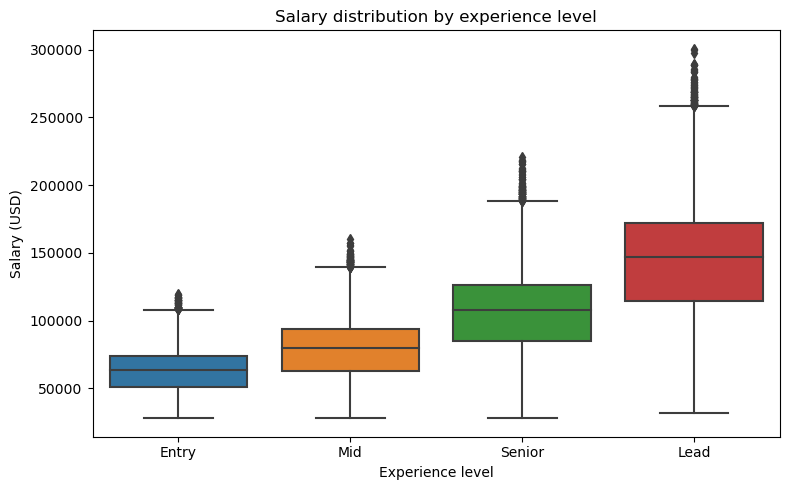

In [11]:
# Salary distribution by experience level
import matplotlib.pyplot as plt
import seaborn as sns

exp_order = ["Entry", "Mid", "Senior", "Lead"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="experience_level",
    y="salary_usd",
    order=exp_order,
)
plt.title("Salary distribution by experience level")
plt.xlabel("Experience level")
plt.ylabel("Salary (USD)")
plt.tight_layout()
plt.show()

### Compensation vs. work–life balance

This scatterplot connects the salary story to work–life balance. Each point represents a job, with salary on the x-axis and work–life balance score on the y-axis, colored by work mode (onsite, hybrid, remote). This lets us see whether higher-paying roles tend to come with worse balance, and whether certain work arrangements cluster in more favorable tradeoff regions.

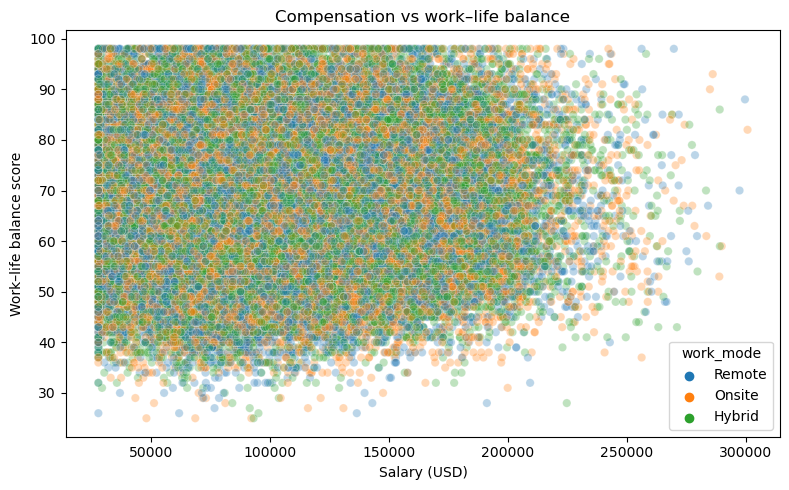

In [12]:
# Compensation vs work–life balance
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="salary_usd",
    y="work_life_balance_score",
    hue="work_mode",
    alpha=0.3,
)

plt.title("Compensation vs work–life balance")
plt.xlabel("Salary (USD)")
plt.ylabel("Work–life balance score")
plt.tight_layout()
plt.show()

## Question 4: Which countries offer the best post-tax, cost-adjusted compensation and work quality for tech roles — and does remote work eliminate the advantage of being in a high-salary country? 

Comment: GDP, McDonald’s price adjustments. Can get discarded. salary_usd, tax_rate_percent, cost_of_living_index, vacation_days, work_life_balance_score, work_mode, country, job_role, experience_level, and salary_percentile. That's enough to compute a real purchasing power metric, compare countries, and run the remote vs. onsite A/B comparison entirely within the dataset. Only possible issues: might not be LIVE values and no city-level granularity.

## Visualization 1: Country Opportunity Map (Compensation vs Work Quality)

This identifies the best countries for tech jobs after adjusting for taxes and cost of living.

X-axis = real purchasing power
Y-axis = work quality

Countries in the top-right corner are the best places to work.

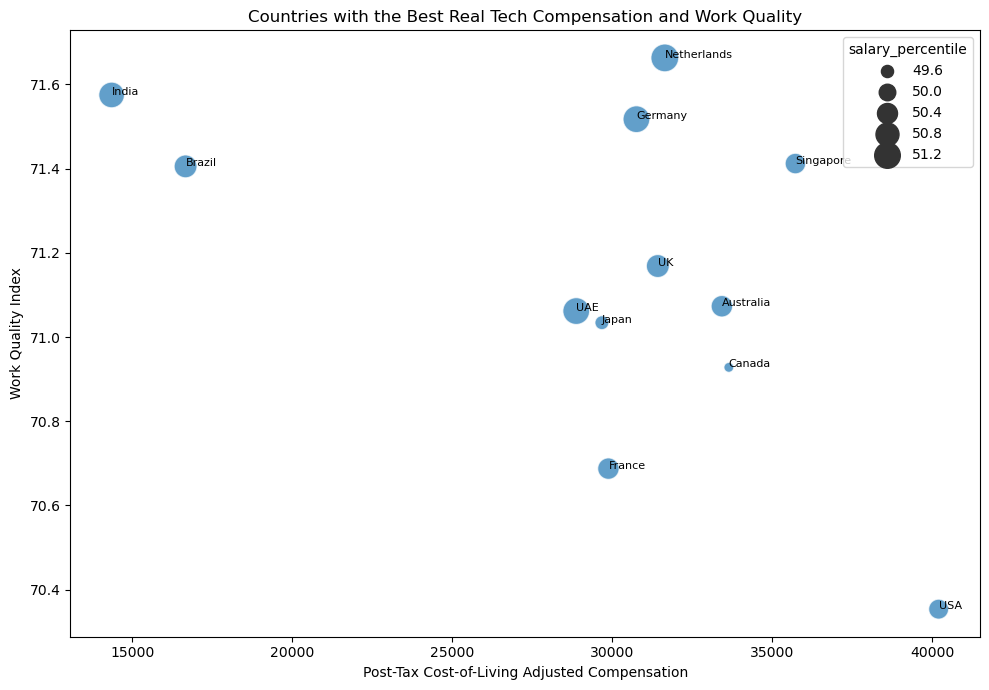

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("global_ai_jobs.csv")

# Create purchasing power metric
df["real_compensation"] = (
    (df["salary_usd"]) *
    (1 - df["tax_rate_percent"]/100) /
    df["cost_of_living_index"]
)

# Create work quality index
df["work_quality"] = (
    df["work_life_balance_score"] +
    df["vacation_days"]/10
)

# Focus on entry-level roles
entry = df[df["experience_level"] == "Entry"]

country_summary = (
    entry.groupby("country")
    .agg({
        "real_compensation":"median",
        "work_quality":"mean",
        "salary_percentile":"mean"
    })
    .reset_index()
)

plt.figure(figsize=(10,7))

sns.scatterplot(
    data=country_summary,
    x="real_compensation",
    y="work_quality",
    size="salary_percentile",
    sizes=(50,400),
    alpha=0.7
)

for i,row in country_summary.iterrows():
    plt.text(
        row["real_compensation"],
        row["work_quality"],
        row["country"],
        fontsize=8
    )

plt.title("Countries with the Best Real Tech Compensation and Work Quality")
plt.xlabel("Post-Tax Cost-of-Living Adjusted Compensation")
plt.ylabel("Work Quality Index")

plt.tight_layout()
plt.show()

## Visualization 2: Remote vs Onsite Compensation Advantage by Country

This answers: Does remote work eliminate country advantages?

If remote jobs flatten country differences, then remote points will cluster closer together than onsite jobs.

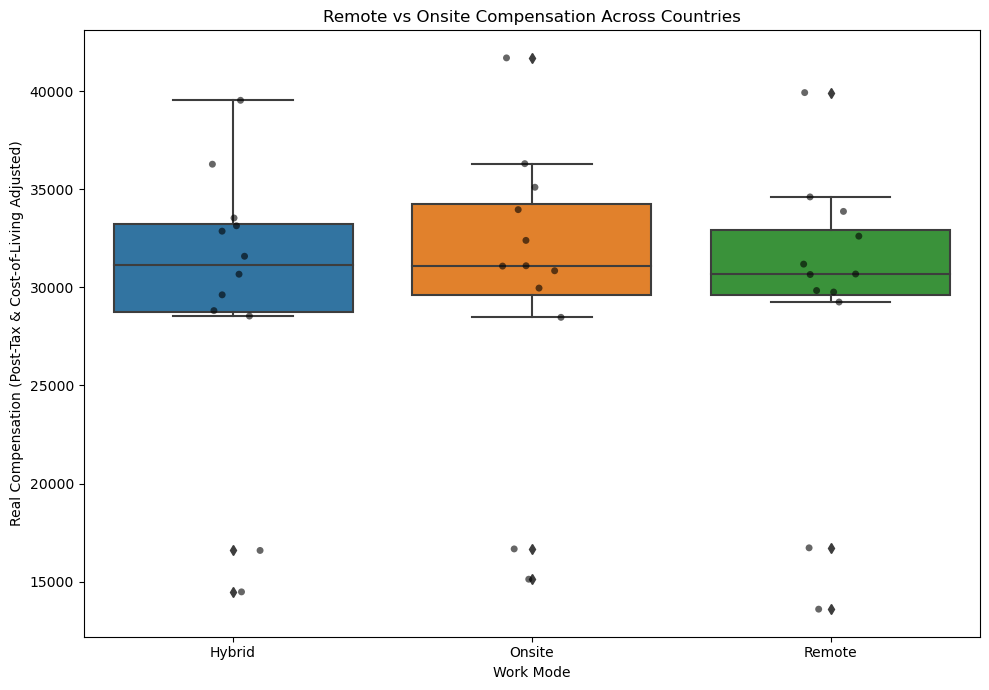

In [15]:
entry = df[df["experience_level"] == "Entry"]

country_workmode = (
    entry.groupby(["country","work_mode"])
    .agg({
        "real_compensation":"median"
    })
    .reset_index()
)

plt.figure(figsize=(10,7))

sns.boxplot(
    data=country_workmode,
    x="work_mode",
    y="real_compensation"
)

sns.stripplot(
    data=country_workmode,
    x="work_mode",
    y="real_compensation",
    color="black",
    alpha=0.6
)

plt.title("Remote vs Onsite Compensation Across Countries")
plt.xlabel("Work Mode")
plt.ylabel("Real Compensation (Post-Tax & Cost-of-Living Adjusted)")

plt.tight_layout()
plt.show()